# 01 — ARIMA / ARIMAX Baseline

Auto-select ARIMA order, add exogenous covariates (ARIMAX), expanding and rolling 1-step-ahead walk-forward forecasts, sentiment comparison, Diebold-Mariano significance test, sub-period robustness, and 2026 zoom.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load features

In [14]:
train = pd.read_csv('../../data/processed/train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('../../data/processed/val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('../../data/processed/test.csv',  index_col=0, parse_dates=True)

TARGET = 'silver_return'
EXOG   = ['gold_return', 'usd_return', 'copper_return', 'sp500_return',
          'vix_return', 'oil_return']

# Log returns are additive: weekly return = sum of 5 daily log returns.
# Resample on week-ending Friday so each bucket is a complete Mon-Fri week.
y_train = train[TARGET].resample('W-FRI').sum().dropna()
y_val   = val[TARGET].resample('W-FRI').sum().dropna()
y_test  = test[TARGET].resample('W-FRI').sum().dropna()

exog_cols = [c for c in EXOG if c in train.columns]
train_w = train[exog_cols].resample('W-FRI').sum()
val_w   = val[exog_cols].resample('W-FRI').sum()
test_w  = test[exog_cols].resample('W-FRI').sum()

print(f'Weekly train: {len(y_train)} weeks | val: {len(y_val)} | test: {len(y_test)}')
print(f'EXOG columns: {exog_cols}')

Weekly train: 365 weeks | val: 52 | test: 175
EXOG columns: ['gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return']


### Why aggregate to weekly?

**Log returns are additive**, so summing 5 daily log-returns gives the exact weekly log-return:

$$\log\frac{P_5}{P_1} = \log\frac{P_2}{P_1} + \log\frac{P_3}{P_2} + \log\frac{P_4}{P_3} + \log\frac{P_5}{P_4}$$

No approximation is involved — this is exact. The same applies to the exogenous market returns.

**Sentiment** is aggregated with `.mean()` instead of `.sum()` — we want the average mood
over the week, not an accumulated score. Sentiment values are bounded in $[-1, 1]$ so summing
them would produce an unbounded number with no clear interpretation.

**Shape after aggregation:**

| Split | Daily | Weekly |
|-------|-------|--------|
| Train | 1 755 rows | ~351 weeks |
| Test  |   500 rows | ~100 weeks |

The 100-week test set is the binding constraint — it is enough for a meaningful evaluation
but directional accuracy estimates will have wider confidence intervals than the daily version.
See `03b_arima_daily.ipynb` for the 1-day-ahead version on the full daily sample.

## 2. Order selection via AIC grid search

In [15]:
best_aic, best_order = np.inf, (1, 0, 1)
results = []

for p in range(0, 5):
    for q in range(0, 5):
        try:
            m = ARIMA(y_train, order=(p, 0, q)).fit()
            results.append({'p': p, 'q': q, 'aic': m.aic, 'bic': m.bic})
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, 0, q)
        except Exception:
            pass

results_df = pd.DataFrame(results).sort_values('aic').head(10)
print(f'Best ARIMA order (weekly): {best_order}  AIC: {best_aic:.2f}')
results_df

Best ARIMA order (weekly): (0, 0, 0)  AIC: -1361.66


,p,q,aic,bic
0,0,0,-1361.655718,-1353.855923
7,1,2,-1359.979500,-1340.480014
1,0,1,-1359.655947,-1347.956255
5,1,0,-1359.655947,-1347.956255
4,0,4,-1357.972107,-1334.572723
20,4,0,-1357.957871,-1334.558487
2,0,2,-1357.702480,-1342.102890
10,2,0,-1357.692825,-1342.093236
6,1,1,-1357.655732,-1342.056142
3,0,3,-1357.064107,-1337.564621


> **Note — ARIMAX(0,0,0) is OLS regression**
>
> Because the AIC search selects order (0,0,0), the ARIMAX model below reduces to
> ordinary least squares on lagged exogenous variables.  This is expected for weekly
> silver returns — there is almost no linear autocorrelation once noise is factored in.
> The value of ARIMAX here is the formal framework for testing whether macro covariates
> add predictive power, not the AR/MA terms themselves.

## 3. Forecast schemes — motivation

Two approaches for generating 1-step-ahead out-of-sample forecasts:

**Expanding window (recursive)**  — trains on *all* available history up to week *t*.
- Pros: uses maximum data; asymptotically efficient.
- Cons: old regimes (pre-2021 silver squeeze) have equal weight as recent ones.

**Rolling window (100 weeks ≈ 2 years)** — trains on the *most recent* 100 weeks only.
- Pros: adapts faster to regime changes; silver has had at least two distinct volatility regimes.
- Cons: discards long-run information.

Both are run and compared. For ARIMAX we only use the rolling window in the sentiment comparison (lower memory, faster re-estimation).

## 3. Walk-forward forecast functions

In [16]:
def recursive_forecast(y_train, y_test, order, exog_train=None, exog_test=None):
    """Expanding-window 1-step-ahead forecast."""
    history = list(y_train)
    preds   = []
    exog_h  = list(exog_train.values) if exog_train is not None else None

    for t in range(len(y_test)):
        exog_f = [exog_test.iloc[t].values] if exog_h is not None else None
        try:
            model = ARIMA(history, order=order,
                          exog=exog_h if exog_h is not None else None).fit()
            fc = model.forecast(steps=1, exog=exog_f)
            preds.append(float(np.asarray(fc).flat[0]))
        except Exception:
            preds.append(np.nan)
        history.append(float(y_test.iloc[t]))
        if exog_h is not None:
            exog_h.append(exog_test.iloc[t].values)
    return np.array(preds)


def rolling_forecast(y_train, y_test, order, window_size=100,
                     exog_train=None, exog_test=None):
    """Fixed-window 1-step-ahead forecast (most recent window_size weeks)."""
    history = list(y_train[-window_size:])
    preds   = []
    exog_h  = list(exog_train.values[-window_size:]) if exog_train is not None else None

    for t in range(len(y_test)):
        exog_f = [exog_test.iloc[t].values] if exog_h is not None else None
        try:
            model = ARIMA(history, order=order,
                          exog=exog_h if exog_h is not None else None).fit()
            fc = model.forecast(steps=1, exog=exog_f)
            preds.append(float(np.asarray(fc).flat[0]))
        except Exception:
            preds.append(np.nan)
        history.append(float(y_test.iloc[t]))
        history.pop(0)
        if exog_h is not None:
            exog_h.append(exog_test.iloc[t].values)
            exog_h.pop(0)
    return np.array(preds)

In [17]:
print('Running ARIMA expanding window (weekly)...')
preds_arima_exp = recursive_forecast(y_train, y_test, best_order)
print('Running ARIMA rolling window (100 weeks)...')
preds_arima_rol = rolling_forecast(y_train, y_test, best_order, window_size=100)
print('Done')

Running ARIMA expanding window (weekly)...
Running ARIMA rolling window (100 weeks)...
Done


## 4. ARIMAX — add exogenous variables

Exogenous variables: `gold_return`, `usd_return`, `copper_return`, `sp500_return`, `vix_return`, `oil_return`.

**Lookahead fix** — at week *t* we do not know this week's macro returns until the week closes.
We therefore lag all exogenous variables by 1 week: the model sees last week's gold/dollar/VIX moves
to predict this week's silver return.

The concat trick with `ignore_index=True` avoids a subtle date-matching bug: naively shifting by
date would give the same-week value for the first test observation.

In [18]:
# Use t-1 exog to predict t (no lookahead)
X_train_lag = train_w[exog_cols].shift(1).reindex(y_train.index).fillna(0)

# Positional lag for test: week 1 of test uses last training week; week 2+ uses prior test week
X_test_lag = pd.concat([
    train_w[exog_cols].iloc[[-1]],
    test_w[exog_cols].iloc[:-1]
], ignore_index=True).fillna(0)
X_test_lag.index = y_test.index

print('Running ARIMAX expanding window (weekly, lagged exog)...')
preds_arimax_exp = recursive_forecast(y_train, y_test, best_order,
                                      exog_train=X_train_lag, exog_test=X_test_lag)
print('Running ARIMAX rolling window (100 weeks, lagged exog)...')
preds_arimax_rol = rolling_forecast(y_train, y_test, best_order, window_size=100,
                                    exog_train=X_train_lag, exog_test=X_test_lag)
print('Done')

Running ARIMAX expanding window (weekly, lagged exog)...
Running ARIMAX rolling window (100 weeks, lagged exog)...
Done


## 5. Evaluate

In [19]:
import sys, os
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import evaluate, period_metrics, diebold_mariano, PERIODS

actuals    = y_test.values
test_index = y_test.index

naive_pred = np.concatenate([[np.nan], actuals[:-1]])

metrics = []
metrics.append(evaluate('Naive (t-1 week)',           actuals, naive_pred))
metrics.append(evaluate('ARIMA expanding',            actuals, preds_arima_exp))
metrics.append(evaluate('ARIMA rolling (100w)',       actuals, preds_arima_rol))
metrics.append(evaluate('ARIMAX expanding',           actuals, preds_arimax_exp))
metrics.append(evaluate('ARIMAX rolling (100w)',      actuals, preds_arimax_rol))

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
metrics_df.to_csv('../../data/processed/metrics_arima.csv', index=False)
metrics_df

Naive (t-1 week)                               RMSE=0.07584  MAE=0.05386  DA=0.494  WDA=0.491
ARIMA expanding                                RMSE=0.05180  MAE=0.03712  DA=0.554  WDA=0.585
ARIMA rolling (100w)                           RMSE=0.05176  MAE=0.03707  DA=0.520  WDA=0.539
ARIMAX expanding                               RMSE=0.05212  MAE=0.03689  DA=0.537  WDA=0.526
ARIMAX rolling (100w)                          RMSE=0.05236  MAE=0.03674  DA=0.566  WDA=0.524


,model,rmse,mae,dir_acc,wda
0,Naive (t-1 week),0.075840,0.053865,0.494253,0.491093
1,ARIMA expanding,0.051800,0.037125,0.554286,0.584791
2,ARIMA rolling (100w),0.051765,0.037070,0.520000,0.538525
3,ARIMAX expanding,0.052117,0.036891,0.537143,0.526216
4,ARIMAX rolling (100w),0.052362,0.036736,0.565714,0.523705


## 6. Predicted vs actual

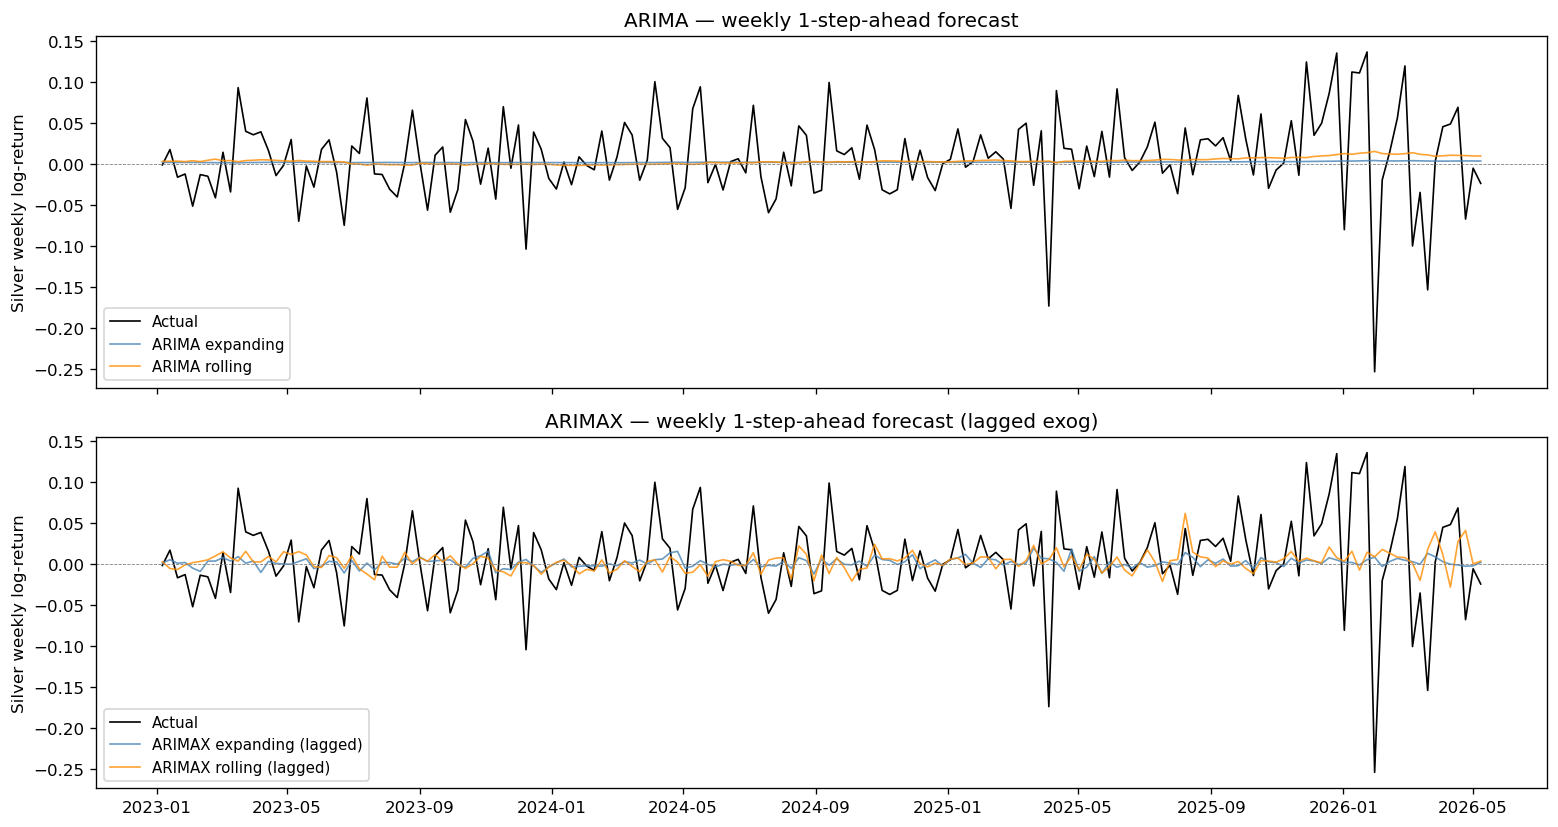

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(test_index, actuals,          label='Actual',           lw=1, color='black')
axes[0].plot(test_index, preds_arima_exp,  label='ARIMA expanding',  lw=1, alpha=0.8, color='steelblue')
axes[0].plot(test_index, preds_arima_rol,  label='ARIMA rolling',    lw=1, alpha=0.8, color='darkorange')
axes[0].axhline(0, color='grey', lw=0.5, ls='--')
axes[0].set_title('ARIMA — weekly 1-step-ahead forecast')
axes[0].set_ylabel('Silver weekly log-return')
axes[0].legend(fontsize=9)

axes[1].plot(test_index, actuals,           label='Actual',                   lw=1, color='black')
axes[1].plot(test_index, preds_arimax_exp,  label='ARIMAX expanding (lagged)', lw=1, alpha=0.8, color='steelblue')
axes[1].plot(test_index, preds_arimax_rol,  label='ARIMAX rolling (lagged)',   lw=1, alpha=0.8, color='darkorange')
axes[1].axhline(0, color='grey', lw=0.5, ls='--')
axes[1].set_title('ARIMAX — weekly 1-step-ahead forecast (lagged exog)')
axes[1].set_ylabel('Silver weekly log-return')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Sentiment comparison

Re-runs ARIMAX rolling (100 weeks) adding different sentiment signals as extra lagged exogenous variables.
All sentiment is lagged by 1 week (same lookahead discipline as the macro variables).

Variants tested:
- **Baseline**: no sentiment (ARIMAX macro only)
- **Reddit only**: weekly mean of Twitter-RoBERTa scores on r/wallstreetbets/silverbugs posts
- **News only**: weekly mean of FinBERT scores on GDELT English headlines
- **Reddit + News**: both signals together
- **Google Trends**: weekly "silver" search interest — retail attention proxy

In [21]:
import os

sent_path  = '../../data/processed/daily_sentiment.csv'
trends_path = '../../data/raw/google_trends.csv'

all_candidates = {
    'ARIMAX expanding':      preds_arimax_exp,
    'ARIMAX rolling (100w)': preds_arimax_rol,
}

if not os.path.exists(sent_path):
    print('daily_sentiment.csv not found — run 03_sentiment.ipynb first.')
else:
    sentiment = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    sent_w    = sentiment[['reddit_sentiment', 'news_sentiment']].resample('W-FRI').mean()

    def build_exog(sent_cols, trend_col=None):
        """Build lagged exog = macro + optional sentiment/trends columns."""
        extra_train = []
        extra_test  = []
        for col in sent_cols:
            s = sent_w[col].reindex(train_w.index.union(test_w.index)).ffill().fillna(0)
            s_train = s.reindex(y_train.index).ffill().fillna(0)
            s_test  = s.reindex(y_test.index).ffill().fillna(0)
            lag_train = s_train.shift(1).fillna(0)
            lag_test  = pd.concat([s_train.iloc[[-1]], s_test.iloc[:-1]], ignore_index=True).fillna(0)
            lag_test.index = y_test.index
            extra_train.append(lag_train.rename(col))
            extra_test.append(lag_test.rename(col))

        if trend_col is not None:
            tr = pd.read_csv(trends_path, index_col=0, parse_dates=True)
            tr.index = tr.index + pd.offsets.Week(weekday=4)  # align to Friday
            ts = tr[trend_col].resample('W-FRI').last().ffill()
            ts_train = ts.reindex(y_train.index).ffill().bfill()
            ts_test  = ts.reindex(y_test.index).ffill().bfill()
            lag_tr = ts_train.shift(1).fillna(0)
            lag_te = pd.concat([ts_train.iloc[[-1]], ts_test.iloc[:-1]], ignore_index=True).fillna(0)
            lag_te.index = y_test.index
            extra_train.append(lag_tr.rename('trends'))
            extra_test.append(lag_te.rename('trends'))

        X_tr = pd.concat([X_train_lag] + extra_train, axis=1).fillna(0)
        X_te = pd.concat([X_test_lag]  + extra_test,  axis=1).fillna(0)
        return X_tr, X_te

    for label, sent_cols, trend_col in [
        ('Reddit only',    ['reddit_sentiment'],                 None),
        ('News only',      ['news_sentiment'],                   None),
        ('Reddit + News',  ['reddit_sentiment','news_sentiment'],None),
        ('Trends',         [],                                   'silver'),
    ]:
        X_tr_s, X_te_s = build_exog(sent_cols, trend_col)
        print('Running ARIMAX+{} rolling (100w)...'.format(label))
        pred = rolling_forecast(y_train, y_test, best_order, window_size=100,
                                exog_train=X_tr_s, exog_test=X_te_s)
        evaluate('ARIMAX+{} rolling (100w)'.format(label), actuals, pred)
        all_candidates['ARIMAX+{} rolling (100w)'.format(label)] = pred

    print()
    print('All variants:')
    for name, pred in all_candidates.items():
        evaluate(name, actuals, pred)

Running ARIMAX+Reddit only rolling (100w)...
ARIMAX+Reddit only rolling (100w)              RMSE=0.05277  MAE=0.03712  DA=0.566  WDA=0.533
Running ARIMAX+News only rolling (100w)...
ARIMAX+News only rolling (100w)                RMSE=0.05233  MAE=0.03665  DA=0.589  WDA=0.572
Running ARIMAX+Reddit + News rolling (100w)...
ARIMAX+Reddit + News rolling (100w)            RMSE=0.05268  MAE=0.03692  DA=0.566  WDA=0.540
Running ARIMAX+Trends rolling (100w)...
ARIMAX+Trends rolling (100w)                   RMSE=0.05440  MAE=0.03754  DA=0.514  WDA=0.501

All variants:
ARIMAX expanding                               RMSE=0.05212  MAE=0.03689  DA=0.537  WDA=0.526
ARIMAX rolling (100w)                          RMSE=0.05236  MAE=0.03674  DA=0.566  WDA=0.524
ARIMAX+Reddit only rolling (100w)              RMSE=0.05277  MAE=0.03712  DA=0.566  WDA=0.533
ARIMAX+News only rolling (100w)                RMSE=0.05233  MAE=0.03665  DA=0.589  WDA=0.572
ARIMAX+Reddit + News rolling (100w)            RMSE=0.0526

## 8. Sub-period robustness: DA and WDA by year

Breaks down the best-performing variant by calendar year to check whether
directional accuracy is stable or driven by one lucky period.

In [22]:
best_name = max(all_candidates, key=lambda k:
    np.nansum(np.abs(actuals) * (np.sign(actuals) == np.sign(all_candidates[k]))) /
    np.nansum(np.abs(actuals)))
best_pred = all_candidates[best_name]
print('Best variant by WDA:', best_name)

res = period_metrics(actuals, best_pred, test_index, PERIODS)
display(res[['n', 'DA', 'WDA']].style
        .format({'n': '{:.0f}', 'DA': '{:.3f}', 'WDA': '{:.3f}'})
        .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.4, vmax=0.7))

Best variant by DA: ARIMAX+News only rolling (100w)


,n,DA,WDA
Period,,,
2023 (choppy),52,0.577,0.587
2024 (bull start),52,0.558,0.516
2025 (bull run),52,0.635,0.681
2026 (YTD),19,0.579,0.477
── Full test ──,175,0.589,0.572


## 9. Diebold-Mariano test

Tests whether sentiment and Trends variants produce statistically significant forecast
improvements over the no-sentiment ARIMAX rolling baseline.

**H0**: equal predictive accuracy (squared error loss).  
A negative DM statistic means the baseline has *larger* errors (challenger is better).  
Newey-West variance correction with lag=1 for weekly autocorrelation.

In [23]:
print('Diebold-Mariano tests -- each variant vs ARIMAX rolling (no sentiment)')
print('H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant')
print('-' * 95)

baseline_key  = 'ARIMAX rolling (100w)'
baseline_pred = all_candidates[baseline_key]
for name, pred in all_candidates.items():
    if name == baseline_key:
        continue
    diebold_mariano(actuals, baseline_pred, pred, baseline_key, name)

Diebold-Mariano tests -- each variant vs ARIMAX rolling (no sentiment)
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant
-----------------------------------------------------------------------------------------------
ARIMAX rolling (100w)                    vs ARIMAX expanding                          DM=+0.517  p=0.605  (ns)
ARIMAX rolling (100w)                    vs ARIMAX+Reddit only rolling (100w)         DM=-0.984  p=0.325  (ns)
ARIMAX rolling (100w)                    vs ARIMAX+News only rolling (100w)           DM=+0.073  p=0.942  (ns)
ARIMAX rolling (100w)                    vs ARIMAX+Reddit + News rolling (100w)       DM=-0.559  p=0.576  (ns)
ARIMAX rolling (100w)                    vs ARIMAX+Trends rolling (100w)              DM=-1.034  p=0.301  (ns)


## 10. 2026 zoom — actual vs best model

Focuses on the most recent out-of-sample period where silver has been most active.

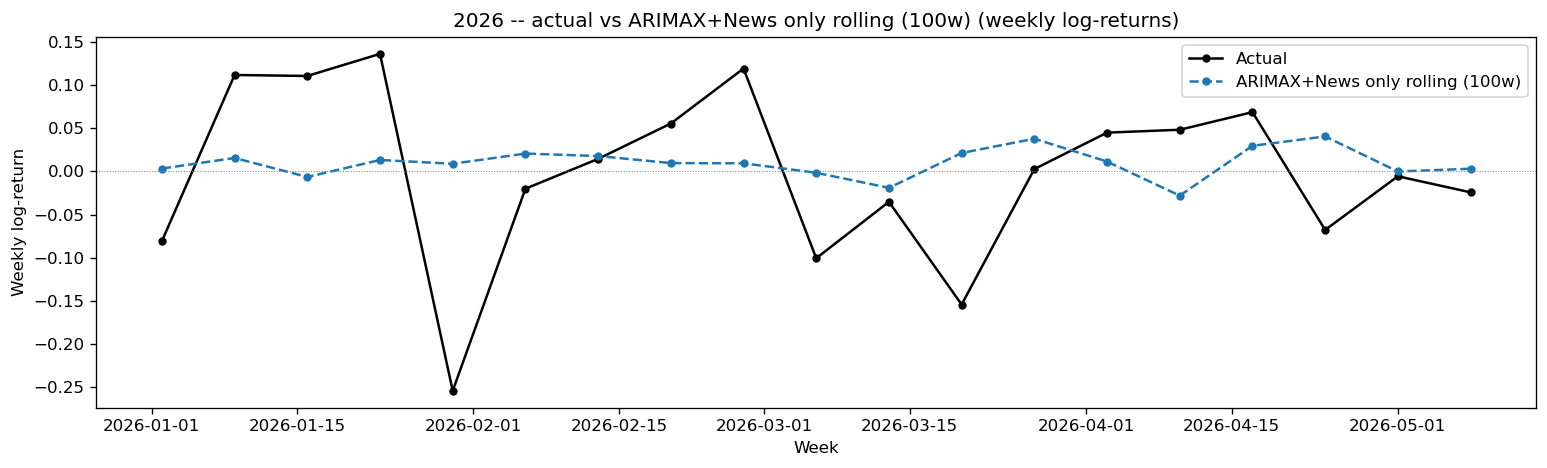

In [24]:
df26 = pd.DataFrame({'actual': actuals, 'pred': best_pred}, index=test_index)
df26 = df26.loc['2026':]

if df26.empty:
    print('No 2026 data in test set yet.')
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(df26.index, df26['actual'], color='black',   lw=1.5, marker='o', ms=4, label='Actual')
    ax.plot(df26.index, df26['pred'],   color='#1f77b4', lw=1.5, marker='o', ms=4,
            ls='--', label=best_name)
    ax.axhline(0, color='grey', lw=0.6, ls=':')
    ax.set_title('2026 -- actual vs {} (weekly log-returns)'.format(best_name), fontsize=12)
    ax.set_ylabel('Weekly log-return')
    ax.set_xlabel('Week')
    ax.legend()
    plt.tight_layout()
    plt.show()